Menilai Buku Dengan Sampulnya

In [ ]:
import os
import shutil
!conda install -y gdown
!gdown --id 1I89aSGNTUj_E_KjHAQy9itJqdJIJ_8Or
!gdown --id 1mMc3scgQlaweg2i0Up4JXW6wl3fjwgLC
!gdown --id 1u__lepxmJ2O9d_zk_UkaZqJpz3XScjdt

!unzip images.zip

/bin/bash: line 1: conda: command not found
/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1I89aSGNTUj_E_KjHAQy9itJqdJIJ_8Or
From (redirected): https://drive.google.com/uc?id=1I89aSGNTUj_E_KjHAQy9itJqdJIJ_8Or&confirm=t&uuid=a4a97a5a-cf4c-48c5-b9d8-e013d2bf5ae1
To: /kaggle/working/images.zip
100%|███████████████████████████████████████| 8.74G/8.74G [01:14<00:00, 118MB/s]
/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1mMc3scgQlaweg2i0Up4JXW6wl3fjwgLC
To: /kaggle/working/book30-listing-test.csv
100%|██████████████████████████████████

In [ ]:
!rm images.zip

1. Importing Package

In [ ]:
import numpy as np
import pandas as pd
import os
from PIL import Image
import cv2
from cv2 import GaussianBlur, equalizeHist, cvtColor, COLOR_RGB2HSV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.base import BaseEstimator, TransformerMixin
from skimage.feature import hog, local_binary_pattern
from skimage.feature import graycomatrix, graycoprops
from tqdm import tqdm # For progress bar
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # For confusion matrix plotting
import time # To measure training time

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

2. Loading Dataset

In [9]:
# 1. First, let's check if the CSV files exist
required_files = ['book30-listing-train.csv', 'book30-listing-test.csv']
for file in required_files:
    if not os.path.exists(file):
        print(f"Warning: {file} not found!")

# 2. Load and inspect training data
try:
    # Try different encodings
    encodings = ['utf-8', 'latin1', 'cp1252', 'iso-8859-1']

    for encoding in encodings:
        try:
            df_train = pd.read_csv('book30-listing-train.csv', encoding=encoding)
            print(f"\nSuccessfully loaded with {encoding} encoding")
            break
        except UnicodeDecodeError:
            continue

    print("\nTraining Data Info:")
    print(f"Number of rows: {len(df_train)}")
    print("\nColumns:")
    print(df_train.columns.tolist())
    print("\nSample data:")
    print(df_train.head())

    # Check for missing values
    print("\nMissing values:")
    print(df_train.isnull().sum())


except Exception as e:
    print(f"Error loading training data: {str(e)}")


Successfully loaded with latin1 encoding

Training Data Info:
Number of rows: 51299

Columns:
['1588345297', '1588345297.jpg', 'http://ecx.images-amazon.com/images/I/51l6XIoa3rL.jpg', 'With Schwarzkopf: Life Lessons of The Bear', 'Gus Lee', '1', 'Biographies & Memoirs']

Sample data:
   1588345297  1588345297.jpg  \
0  1404803335  1404803335.jpg   
1  1446276082  1446276082.jpg   
2  1491522666  1491522666.jpg   
3   970096410  0970096410.jpg   
4  8436808053  8436808053.jpg   

  http://ecx.images-amazon.com/images/I/51l6XIoa3rL.jpg  \
0  http://ecx.images-amazon.com/images/I/51UJnL3T...      
1  http://ecx.images-amazon.com/images/I/51MGUKhk...      
2  http://ecx.images-amazon.com/images/I/51qKvjsi...      
3  http://ecx.images-amazon.com/images/I/51qoUENb...      
4  http://ecx.images-amazon.com/images/I/41aDW5pz...      

          With Schwarzkopf: Life Lessons of The Bear              Gus Lee   1  \
0  Magnets: Pulling Together, Pushing Apart (Amaz...  Natalie M. Rosinsky   4  

3. Data Cleaning and pruning

In [10]:
column_names = [
    'Amazon ID',
    'Filename',
    'Image URL',
    'Title',
    'Author',
    'Category ID',
    'Category'
]

# Categories to remove based on our "hunch"
categories_to_remove = [
    'Calendars',
    'Christian Books & Bibles',
    'Test Preparation'
]

# Maximum samples per category for pruning
max_samples_per_category = 1500
random_state_sampling = 42 # For reproducibility of sampling

# Load the data with correct column names
try:
    df_train = pd.read_csv('book30-listing-train.csv',
                          encoding='latin1',
                          names=column_names,
                          skiprows=1)  # Skip header row if it exists

    print("\nDataset Summary (Initial Load):")
    print(f"Total books: {len(df_train)}")
    print(f"\nCategory distribution (Initial Load):")
    print(df_train['Category'].value_counts().head()) # Show top categories

    # Basic data cleaning (removing rows with missing essential data)
    print("\nMissing values before initial dropna:")
    print(df_train.isnull().sum())
    df_train = df_train.dropna(subset=['Image URL', 'Category'])
    print("\nMissing values after initial dropna:")
    print(df_train.isnull().sum())
    print(f"Total books after initial dropna: {len(df_train)}")

    # --- Step 1: Remove specified categories ---
    print(f"\nRemoving the following categories: {', '.join(categories_to_remove)}")
    mask_keep_categories = ~df_train['Category'].isin(categories_to_remove)
    df_train = df_train[mask_keep_categories]
    print(f"Total books after removing selected categories: {len(df_train)}")
    print(f"\nCategory distribution (After Removing Categories):")
    print(df_train['Category'].value_counts())
    print(f"Number of unique categories after removal: {df_train['Category'].nunique()}")

    # --- Step 2: Prune each category to max_samples_per_category ---
    print(f"\nPruning each category to a maximum of {max_samples_per_category} samples...")
    
    # Group by category, then sample, then combine
    # Using .sample(n=min(len(x), max_samples_per_category)...) handles categories that might already have < max_samples
    # although in this dataset, after initial load, they all have > 1500.
    df_train = df_train.groupby('Category', group_keys=False).apply(
        lambda x: x.sample(n=min(len(x), max_samples_per_category), random_state=random_state_sampling)
    )
    # df_train = df_train.reset_index(drop=True) # Reset index after sampling if needed, groupby().apply() might create a multi-index

    print(f"\nTotal books after pruning categories: {len(df_train)}")
    print(f"\nCategory distribution (After Pruning):")
    print(df_train['Category'].value_counts())
    print(f"Number of unique categories after pruning: {df_train['Category'].nunique()}")

    print("\nMissing values after all cleaning and pruning steps:")
    print(df_train.isnull().sum())

    # Save the cleaned and pruned dataset for later use
    df_train.to_csv('book30-listing-train-cleaned.csv', index=False)
    print(f"\nCleaned and pruned dataset saved to 'book30-listing-train-cleaned.csv'")

except Exception as e:
    print(f"Error processing data: {str(e)}")


Dataset Summary (Initial Load):
Total books: 51299

Category distribution (Initial Load):
Category
Children's Books                1710
Engineering & Transportation    1710
Christian Books & Bibles        1710
Sports & Outdoors               1710
Health, Fitness & Dieting       1710
Name: count, dtype: int64

Missing values before initial dropna:
Amazon ID         0
Filename          0
Image URL         0
Title             0
Author         3439
Category ID       0
Category          0
dtype: int64

Missing values after initial dropna:
Amazon ID         0
Filename          0
Image URL         0
Title             0
Author         3439
Category ID       0
Category          0
dtype: int64
Total books after initial dropna: 51299

Removing the following categories: Calendars, Christian Books & Bibles, Test Preparation
Total books after removing selected categories: 46169

Category distribution (After Removing Categories):
Category
Children's Books                1710
Engineering & Transporta

4. Data Splitting

Loading dataset from: book30-listing-train-cleaned.csv
Loaded 40500 records from CSV
Initial memory usage: 9416.8 MB
Loading images from: images/
Processing in batches of 100
Processed 1000/40500 records. Loaded: 1000, Missing: 0, Memory: 9558.3 MB
Processed 2000/40500 records. Loaded: 2000, Missing: 0, Memory: 9701.7 MB
Processed 3000/40500 records. Loaded: 3000, Missing: 0, Memory: 9845.2 MB
Processed 4000/40500 records. Loaded: 3746, Missing: 254, Memory: 9945.8 MB
Processed 5000/40500 records. Loaded: 4607, Missing: 393, Memory: 10075.0 MB
Processed 6000/40500 records. Loaded: 5607, Missing: 393, Memory: 10218.5 MB
Processed 7000/40500 records. Loaded: 6607, Missing: 393, Memory: 10362.0 MB
Processed 8000/40500 records. Loaded: 7607, Missing: 393, Memory: 10505.6 MB
Processed 9000/40500 records. Loaded: 8607, Missing: 393, Memory: 10649.2 MB
Processed 10000/40500 records. Loaded: 9607, Missing: 393, Memory: 10792.8 MB
Processed 11000/40500 records. Loaded: 10607, Missing: 393, Memo

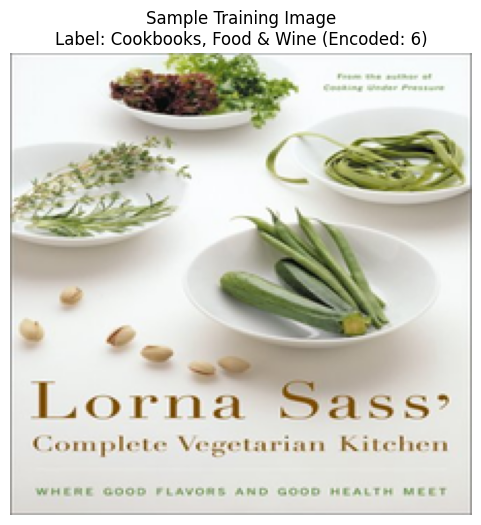

In [11]:
import os
import pandas as pd
import numpy as np
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import gc
from typing import Generator, Tuple, Optional, List
import psutil

# Configuration
CLEANED_CSV_PATH = 'book30-listing-train-cleaned.csv'
BASE_IMAGE_DIR = 'images/'
TARGET_IMAGE_SIZE = (224, 224)
TEST_SPLIT_SIZE = 0.2
RANDOM_STATE_SPLIT = 42
BATCH_SIZE = 100  # Process images in batches to control memory
MEMORY_LIMIT_MB = 2000  # Stop loading if memory exceeds this limit

class MemoryEfficientImageLoader:
    """Memory-efficient image loader with batch processing and memory monitoring"""
    
    def __init__(self, base_image_dir: str, target_size: Tuple[int, int], 
                 batch_size: int = 100, memory_limit_mb: int = 16000):
        self.base_image_dir = base_image_dir
        self.target_size = target_size
        self.batch_size = batch_size
        self.memory_limit_mb = memory_limit_mb
        self.process = psutil.Process(os.getpid())
        
    def get_memory_usage_mb(self) -> float:
        """Get current memory usage in MB"""
        return self.process.memory_info().rss / 1024 / 1024
    
    def load_and_preprocess_image(self, category: str, image_filename: str) -> Optional[np.ndarray]:
        """Optimized image loading with memory cleanup"""
        category_folder_name = str(category)
        image_filename = str(image_filename)
        image_path = os.path.join(self.base_image_dir, category_folder_name, image_filename)

        if not os.path.exists(image_path):
            return None
        
        try:
            # Use context manager for automatic cleanup
            with Image.open(image_path) as img_pil:
                # Convert to RGB efficiently
                if img_pil.mode != 'RGB':
                    img_pil = img_pil.convert('RGB')
                
                # Resize efficiently
                img_pil_resized = img_pil.resize(self.target_size, Image.Resampling.LANCZOS)
                
                # Convert to array
                img_array = np.array(img_pil_resized, dtype=np.uint8)
                
                # Validate shape
                if img_array.shape != (*self.target_size, 3):
                    return None
                
                return img_array
                
        except Exception as e:
            print(f"Error loading {image_path}: {e}")
            return None
    
    def load_images_generator(self, df: pd.DataFrame) -> Generator[Tuple[np.ndarray, str], None, None]:
        """Generator that yields images one at a time"""
        for index, row in df.iterrows():
            image_filename = str(row['Filename'])
            category = str(row['Category'])
            
            img_array = self.load_and_preprocess_image(category, image_filename)
            
            if img_array is not None:
                yield img_array, category
            
            # Memory check every 100 images
            if index % 100 == 0:
                current_memory = self.get_memory_usage_mb()
                if current_memory > self.memory_limit_mb:
                    print(f"Warning: Memory usage ({current_memory:.1f} MB) exceeds limit ({self.memory_limit_mb} MB)")
                    gc.collect()
    
    def load_images_in_batches(self, df: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray]:
        """Load images in batches with memory management"""
        all_images = []
        all_labels = []
        missing_count = 0
        processed_count = 0
        
        print(f"Loading images from: {self.base_image_dir}")
        print(f"Processing in batches of {self.batch_size}")
        
        # Pre-allocate batch arrays
        batch_images = np.empty((self.batch_size, *self.target_size, 3), dtype=np.uint8)
        batch_labels = []
        batch_idx = 0
        
        for index, row in df.iterrows():
            image_filename = str(row['Filename'])
            category = str(row['Category'])
            
            img_array = self.load_and_preprocess_image(category, image_filename)
            
            if img_array is not None:
                batch_images[batch_idx] = img_array
                batch_labels.append(category)
                batch_idx += 1
                processed_count += 1
                
                # When batch is full or we're at the end
                if batch_idx == self.batch_size or index == len(df) - 1:
                    # Add current batch to results
                    if batch_idx > 0:
                        all_images.append(batch_images[:batch_idx].copy())
                        all_labels.extend(batch_labels)
                    
                    # Reset batch
                    batch_labels = []
                    batch_idx = 0
                    
                    # Force garbage collection
                    gc.collect()
                    
                    # Memory monitoring
                    current_memory = self.get_memory_usage_mb()
                    if current_memory > self.memory_limit_mb:
                        print(f"Warning: High memory usage ({current_memory:.1f} MB)")
            else:
                missing_count += 1
            
            # Progress reporting
            if (index + 1) % 1000 == 0:
                current_memory = self.get_memory_usage_mb()
                print(f"Processed {index + 1}/{len(df)} records. "
                      f"Loaded: {processed_count}, Missing: {missing_count}, "
                      f"Memory: {current_memory:.1f} MB")
        
        # Combine all batches efficiently
        if all_images:
            final_images = np.vstack(all_images)
            del all_images  # Free intermediate memory
            gc.collect()
        else:
            final_images = np.array([])
        
        print(f"Finished loading. Total images: {processed_count}, Missing: {missing_count}")
        return final_images, np.array(all_labels)

def load_dataset_efficiently(cleaned_csv_path: str, base_image_dir: str, 
                           target_size: Tuple[int, int] = (224, 224),
                           batch_size: int = 100) -> Tuple:
    """Main function to load dataset efficiently"""
    
    # Load CSV
    print(f"Loading dataset from: {cleaned_csv_path}")
    if not os.path.exists(cleaned_csv_path):
        print(f"ERROR: CSV file not found at {cleaned_csv_path}")
        return None, None, None, None, None
    
    df_cleaned = pd.read_csv(cleaned_csv_path)
    print(f"Loaded {len(df_cleaned)} records from CSV")
    
    if df_cleaned.empty:
        return None, None, None, None, None
    
    # Initialize loader
    loader = MemoryEfficientImageLoader(
        base_image_dir=base_image_dir,
        target_size=target_size,
        batch_size=batch_size
    )
    
    initial_memory = loader.get_memory_usage_mb()
    print(f"Initial memory usage: {initial_memory:.1f} MB")
    
    # Load images
    X, y_strings = loader.load_images_in_batches(df_cleaned)
    
    if len(X) == 0:
        print("ERROR: No images were loaded")
        return None, None, None, None, None
    
    # Encode labels efficiently
    print("\nEncoding labels...")
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y_strings)
    print(f"Found {len(label_encoder.classes_)} unique categories")
    
    # Clean up intermediate variables
    del y_strings
    gc.collect()
    
    # Split data
    print(f"\nSplitting data (test_size={TEST_SPLIT_SIZE})...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=TEST_SPLIT_SIZE,
        random_state=RANDOM_STATE_SPLIT,
        stratify=y
    )
    
    # Clean up original arrays
    del X, y
    gc.collect()
    
    final_memory = loader.get_memory_usage_mb()
    print(f"\nMemory usage: {initial_memory:.1f} MB -> {final_memory:.1f} MB "
          f"(+{final_memory - initial_memory:.1f} MB)")
    
    print(f"\nDataset loaded successfully!")
    print(f"Training images: {X_train.shape}")
    print(f"Test images: {X_test.shape}")
    print(f"Training labels: {y_train.shape}")
    print(f"Test labels: {y_test.shape}")
    
    return X_train, X_test, y_train, y_test, label_encoder

# Alternative: Stream-based loader for very large datasets
class StreamingImageLoader:
    """For datasets too large to fit in memory"""
    
    def __init__(self, base_image_dir: str, target_size: Tuple[int, int]):
        self.base_image_dir = base_image_dir
        self.target_size = target_size
    
    def image_generator(self, df: pd.DataFrame) -> Generator[Tuple[np.ndarray, str], None, None]:
        """Generator that yields one image at a time"""
        loader = MemoryEfficientImageLoader(self.base_image_dir, self.target_size)
        
        for _, row in df.iterrows():
            img_array = loader.load_and_preprocess_image(
                str(row['Category']), str(row['Filename'])
            )
            if img_array is not None:
                yield img_array, str(row['Category'])
    
    def save_processed_dataset(self, df: pd.DataFrame, output_dir: str, 
                             chunk_size: int = 1000):
        """Save processed images in chunks to disk"""
        os.makedirs(output_dir, exist_ok=True)
        
        chunk_images = []
        chunk_labels = []
        chunk_idx = 0
        
        for img_array, category in self.image_generator(df):
            chunk_images.append(img_array)
            chunk_labels.append(category)
            
            if len(chunk_images) >= chunk_size:
                # Save chunk
                np.save(f"{output_dir}/images_chunk_{chunk_idx}.npy", 
                       np.array(chunk_images))
                np.save(f"{output_dir}/labels_chunk_{chunk_idx}.npy", 
                       np.array(chunk_labels))
                
                # Reset
                chunk_images = []
                chunk_labels = []
                chunk_idx += 1
                print(f"Saved chunk {chunk_idx}")
                gc.collect()

def visualize_sample_with_cleanup(X_train: np.ndarray, y_train: np.ndarray, 
                                label_encoder: LabelEncoder):
    """Display sample image with proper memory cleanup"""
    if len(X_train) > 0:
        plt.figure(figsize=(6, 6))
        plt.imshow(X_train[0])
        
        original_label = label_encoder.inverse_transform([y_train[0]])[0]
        plt.title(f"Sample Training Image\nLabel: {original_label} (Encoded: {y_train[0]})")
        plt.axis('off')
        plt.show()
        
        # Cleanup
        plt.close()
        gc.collect()

# Main execution
if __name__ == "__main__":
    # Load dataset efficiently
    X_train_images, X_test_images, y_train, y_test, label_encoder = load_dataset_efficiently(
        CLEANED_CSV_PATH, BASE_IMAGE_DIR, TARGET_IMAGE_SIZE, BATCH_SIZE
    )
    
    if X_train_images is not None:
        # Display sample
        visualize_sample_with_cleanup(X_train_images, y_train, label_encoder)
        
        # Optional: For very large datasets, use streaming approach
        # streaming_loader = StreamingImageLoader(BASE_IMAGE_DIR, TARGET_IMAGE_SIZE)
        # streaming_loader.save_processed_dataset(df_cleaned, "processed_chunks/")
    else:
        print("Failed to load dataset. Check file paths and try again.")

3. Image Preprocessing

Initial memory usage: 15086.76 MB
Processing training images...
Processing test images...
Final memory usage: 20744.48 MB
Memory increase: 5657.73 MB
Preprocessing steps visualization:


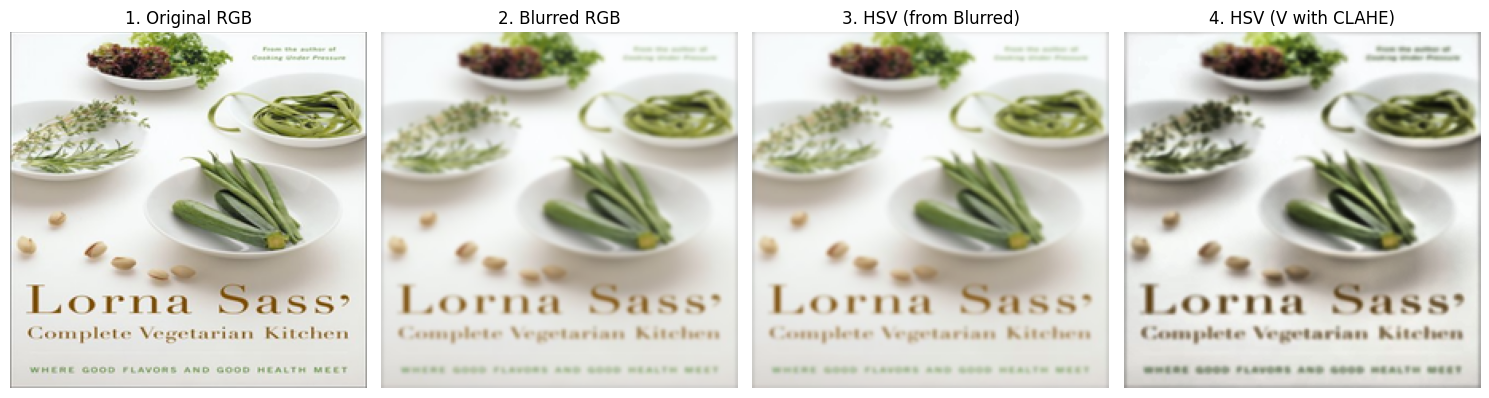

Processed data shapes:
Training: (31528, 224, 224, 3)
Testing: (7883, 224, 224, 3)


In [13]:
import cv2
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
import matplotlib.pyplot as plt
from typing import Generator, Optional, Union
import gc

class ImagePreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self, blur_kernel=(5,5), batch_size=32):
        self.blur_kernel = blur_kernel
        self.batch_size = batch_size
        # Pre-create CLAHE object to avoid repeated instantiation
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        """Memory-efficient transform using generator-based processing"""
        if len(X) == 0:
            return np.array([])
        
        # Process in batches to control memory usage
        return self._batch_transform(X)
    
    def _batch_transform(self, X):
        """Process images in batches to minimize memory footprint"""
        total_images = len(X)
        result_shape = (total_images,) + X[0].shape[:2] + (3,)  # Assuming 3-channel output
        
        # Pre-allocate result array
        processed_images = np.empty(result_shape, dtype=X.dtype)
        
        for i in range(0, total_images, self.batch_size):
            end_idx = min(i + self.batch_size, total_images)
            batch = X[i:end_idx]
            
            # Process batch
            for j, img in enumerate(batch):
                processed_images[i + j] = self._process_single_image(img)
            
            # Force garbage collection after each batch
            del batch
            gc.collect()
        
        return processed_images
    
    def _process_single_image(self, img):
        """Process single image with minimal memory allocation"""
        # Use in-place operations where possible
        blurred = cv2.GaussianBlur(img, self.blur_kernel, 0)
        
        # Convert to HSV (reuse blurred array if possible)
        hsv = cv2.cvtColor(blurred, cv2.COLOR_RGB2HSV)
        
        # Apply CLAHE directly to V channel (in-place)
        hsv[:, :, 2] = self.clahe.apply(hsv[:, :, 2])
        
        return hsv
    
    def transform_generator(self, X):
        """Generator version for even lower memory usage"""
        for img in X:
            yield self._process_single_image(img)

# Memory-efficient preprocessing function
def preprocess_images_efficiently(X_train_images, X_test_images, batch_size=32):
    """
    Efficiently preprocess images with controlled memory usage
    """
    preprocessor = ImagePreprocessor(batch_size=batch_size)
    
    # Store original for visualization (only if needed)
    original_image_for_viz = X_train_images[0].copy() if len(X_train_images) > 0 else None
    
    print("Processing training images...")
    X_train_processed = preprocessor.fit_transform(X_train_images)
    
    # Clear intermediate variables and force garbage collection
    gc.collect()
    
    print("Processing test images...")
    X_test_processed = preprocessor.transform(X_test_images)
    
    return X_train_processed, X_test_processed, original_image_for_viz, preprocessor

# Optimized visualization function with memory cleanup
def visualize_preprocessing(original_image: Optional[np.ndarray], 
                          preprocessor: Optional[ImagePreprocessor] = None):
    """
    Memory-efficient visualization with proper cleanup
    """
    if original_image is None:
        print("No image available for visualization.")
        return
    
    fig, axes = plt.subplots(1, 4, figsize=(15, 5))
    
    try:
        # Stage 1: Original Image
        axes[0].imshow(original_image)
        axes[0].set_title('1. Original RGB')
        axes[0].axis('off')
        
        # Stage 2: Blurred Image (create temporary copy)
        blurred_viz = cv2.GaussianBlur(original_image, (5,5), 0)
        axes[1].imshow(blurred_viz)
        axes[1].set_title('2. Blurred RGB')
        axes[1].axis('off')
        
        # Stage 3: HSV Conversion
        hsv_viz = cv2.cvtColor(blurred_viz, cv2.COLOR_RGB2HSV)
        rgb_from_hsv = cv2.cvtColor(hsv_viz, cv2.COLOR_HSV2RGB)
        axes[2].imshow(rgb_from_hsv)
        axes[2].set_title('3. HSV (from Blurred)')
        axes[2].axis('off')
        
        # Stage 4: After CLAHE
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        hsv_viz[:, :, 2] = clahe.apply(hsv_viz[:, :, 2])
        rgb_final = cv2.cvtColor(hsv_viz, cv2.COLOR_HSV2RGB)
        axes[3].imshow(rgb_final)
        axes[3].set_title('4. HSV (V with CLAHE)')
        axes[3].axis('off')
        
        plt.tight_layout()
        plt.show()
        
    finally:
        # Clean up temporary variables
        locals_to_clean = ['blurred_viz', 'hsv_viz', 'rgb_from_hsv', 'rgb_final']
        for var_name in locals_to_clean:
            if var_name in locals():
                del locals()[var_name]
        gc.collect()

# Usage example with memory monitoring
def process_with_memory_monitoring(X_train_images, X_test_images, batch_size=32):
    """
    Process images with memory usage monitoring
    """
    import psutil
    import os
    
    process = psutil.Process(os.getpid())
    initial_memory = process.memory_info().rss / 1024 / 1024  # MB
    
    print(f"Initial memory usage: {initial_memory:.2f} MB")
    
    # Process images efficiently
    X_train_processed, X_test_processed, original_viz, preprocessor = preprocess_images_efficiently(
        X_train_images, X_test_images, batch_size
    )
    
    final_memory = process.memory_info().rss / 1024 / 1024  # MB
    print(f"Final memory usage: {final_memory:.2f} MB")
    print(f"Memory increase: {final_memory - initial_memory:.2f} MB")
    
    # Visualize preprocessing
    print("Preprocessing steps visualization:")
    visualize_preprocessing(original_viz, preprocessor)
    
    print("Processed data shapes:")
    print(f"Training: {X_train_processed.shape}")
    print(f"Testing: {X_test_processed.shape}")
    
    return X_train_processed, X_test_processed

# Alternative: Ultra low-memory generator approach
class StreamingImagePreprocessor(ImagePreprocessor):
    """
    Streaming version that processes images one at a time
    Use this for very large datasets that don't fit in memory
    """
    
    def transform_streaming(self, X):
        """
        Returns a generator that yields processed images one at a time
        Use this when you can't store all processed images in memory
        """
        for img in X:
            yield self._process_single_image(img)
    
    def save_processed_batch(self, X, output_path, batch_size=100):
        """
        Process and save images in batches to disk
        """
        for i, processed_img in enumerate(self.transform_streaming(X)):
            if i % batch_size == 0:
                print(f"Processed {i} images...")
            
            # Save individual processed image
            filename = f"{output_path}/processed_{i:06d}.npy"
            np.save(filename, processed_img)

# Main execution
if __name__ == "__main__":
    # Example usage:
    X_train_processed, X_test_processed = process_with_memory_monitoring(
        X_train_images, X_test_images, batch_size=16
     )

4. Feature Extraction

Extracting training features...
Extracting features from 31528 images...


Processing batches:   0%|          | 1/1262 [00:00<16:09,  1.30it/s]

Processing batches:   0%|          | 2/1262 [00:01<15:57,  1.32it/s]

Processing batches:   0%|          | 3/1262 [00:02<16:08,  1.30it/s]

Processing batches:   0%|          | 4/1262 [00:03<15:58,  1.31it/s]

...

Processing batches:  99%|█████████▉| 313/316 [04:06<00:02,  1.16it/s]

Processing batches:  99%|█████████▉| 314/316 [04:07<00:01,  1.17it/s]

Processing batches: 100%|█████████▉| 315/316 [04:08<00:00,  1.16it/s]

Processing batches: 100%|██████████| 316/316 [04:08<00:00,  1.27it/s]

Feature extraction complete. Valid images: 7883/7883
Memory: 22127.7 -> 22480.2 MB (+352.5 MB)
Test features shape: (7883, 11722)

Visualizing features for first image...


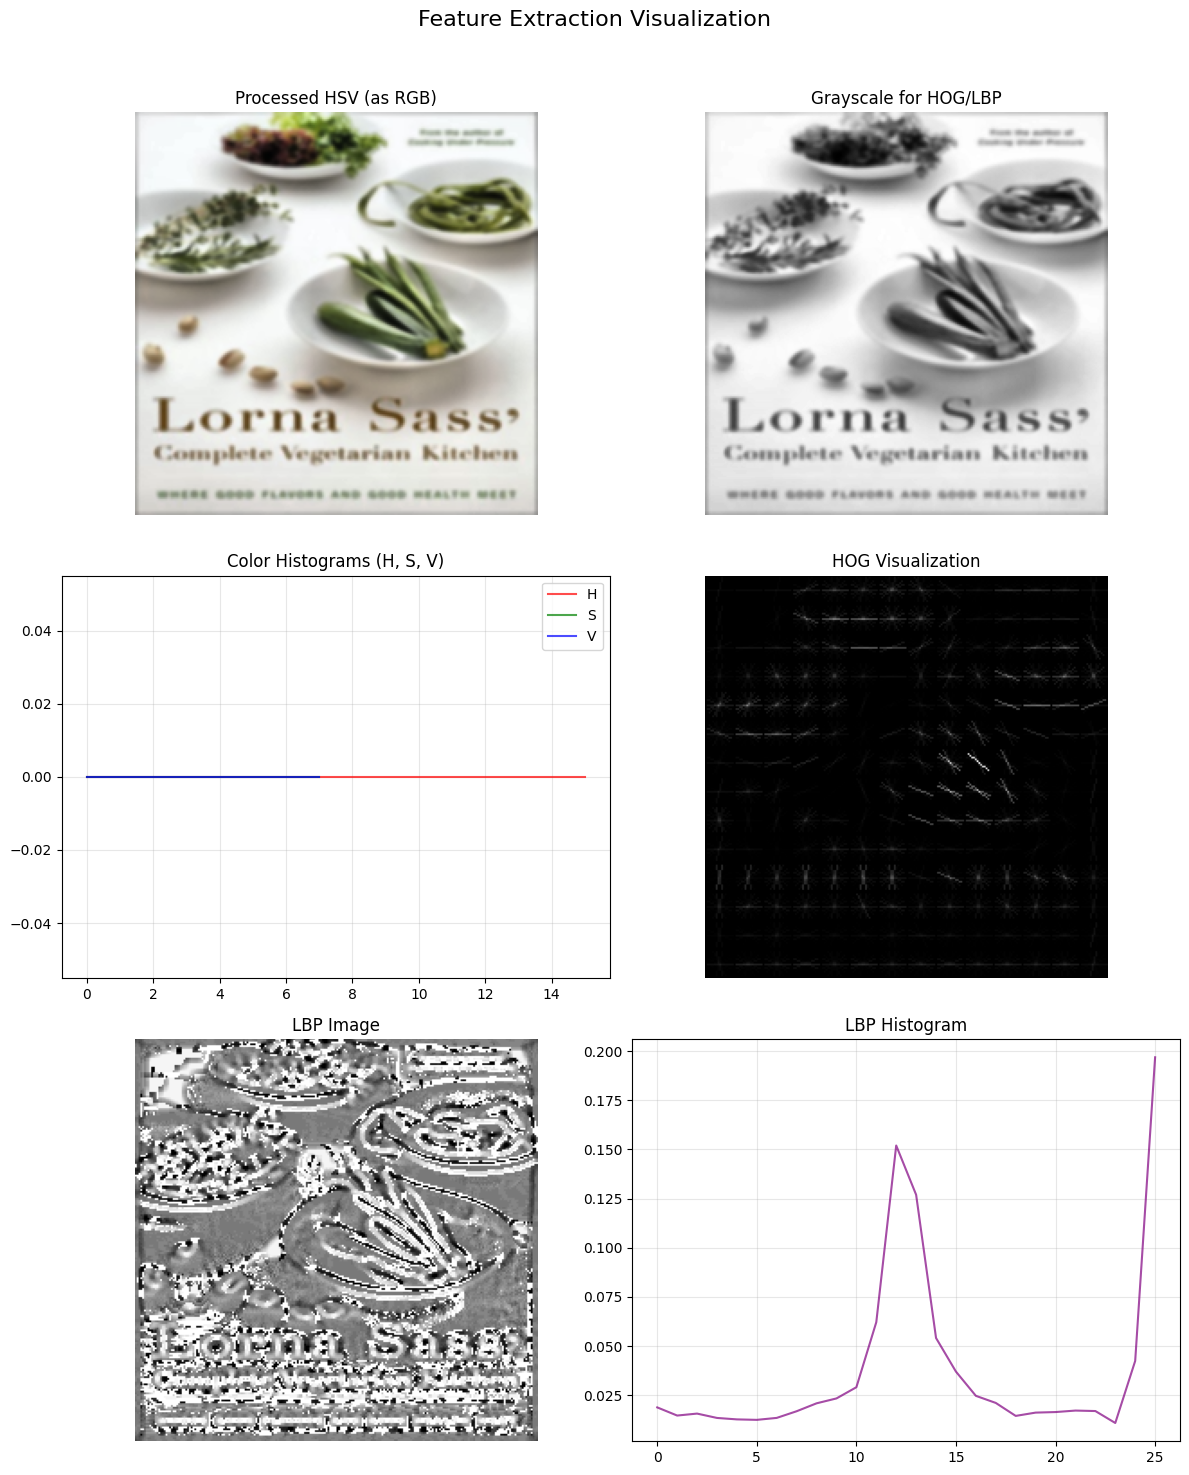

In [14]:
import numpy as np
import cv2
from skimage.feature import hog, local_binary_pattern
from sklearn.base import BaseEstimator, TransformerMixin
from tqdm import tqdm
import matplotlib.pyplot as plt
import gc
import psutil
from typing import Generator, Tuple, Optional, Union, List
import os

class MemoryEfficientFeatureExtractor(BaseEstimator, TransformerMixin):
    """Memory-optimized feature extractor with batch processing and cleanup"""
    
    def __init__(self,
                 color_bins_h=16, color_bins_s=8, color_bins_v=8,
                 hog_params=None,
                 lbp_radius=3,
                 lbp_n_points=24,
                 batch_size=50,  # Process in batches
                 memory_limit_mb=1500):  # Memory limit
        
        self.color_bins_h = color_bins_h
        self.color_bins_s = color_bins_s
        self.color_bins_v = color_bins_v
        self.lbp_radius = lbp_radius
        self.lbp_n_points = lbp_n_points
        self.batch_size = batch_size
        self.memory_limit_mb = memory_limit_mb
        
        # Pre-calculate feature dimensions
        self.color_feature_dim = color_bins_h + color_bins_s + color_bins_v
        self.lbp_feature_dim = lbp_n_points + 2
        
        # Optimized HOG parameters
        default_hog_params = {
            'orientations': 9,
            'pixels_per_cell': (8, 8),
            'cells_per_block': (2, 2),
            'visualize': False,
            'transform_sqrt': True,
            'block_norm': 'L2-Hys',
            'feature_vector': True
        }
        self.hog_params = default_hog_params.copy()
        if hog_params:
            self.hog_params.update(hog_params)
        
        # Pre-allocate reusable arrays
        self._gray_cache = None
        self._rgb_cache = None
        
        # Memory monitoring
        self.process = psutil.Process(os.getpid())
    
    def get_memory_usage_mb(self) -> float:
        """Get current memory usage"""
        return self.process.memory_info().rss / 1024 / 1024
    
    def fit(self, X, y=None):
        return self
    
    def _extract_color_histogram_optimized(self, image_hsv: np.ndarray) -> np.ndarray:
        """Optimized color histogram extraction with pre-allocated arrays"""
        # Pre-allocate result array
        result = np.empty(self.color_feature_dim, dtype=np.float32)
        
        # Extract histograms efficiently
        hist_h = cv2.calcHist([image_hsv], [0], None, [self.color_bins_h], [0, 180])
        cv2.normalize(hist_h, hist_h, alpha=0, beta=1, norm_type=cv2.NORM_L1)
        result[:self.color_bins_h] = hist_h.flatten()
        
        hist_s = cv2.calcHist([image_hsv], [1], None, [self.color_bins_s], [0, 256])
        cv2.normalize(hist_s, hist_s, alpha=0, beta=1, norm_type=cv2.NORM_L1)
        result[self.color_bins_h:self.color_bins_h + self.color_bins_s] = hist_s.flatten()
        
        hist_v = cv2.calcHist([image_hsv], [2], None, [self.color_bins_v], [0, 256])
        cv2.normalize(hist_v, hist_v, alpha=0, beta=1, norm_type=cv2.NORM_L1)
        result[self.color_bins_h + self.color_bins_s:] = hist_v.flatten()
        
        return result
    
    def _get_grayscale_efficiently(self, image_hsv: np.ndarray) -> np.ndarray:
        """Convert HSV to grayscale efficiently with caching"""
        h, w = image_hsv.shape[:2]
        
        # Reuse RGB cache if same size
        if self._rgb_cache is None or self._rgb_cache.shape[:2] != (h, w):
            self._rgb_cache = np.empty((h, w, 3), dtype=image_hsv.dtype)
        
        # Reuse grayscale cache if same size
        if self._gray_cache is None or self._gray_cache.shape != (h, w):
            self._gray_cache = np.empty((h, w), dtype=np.uint8)
        
        # Convert HSV -> RGB -> Gray using cached arrays
        cv2.cvtColor(image_hsv, cv2.COLOR_HSV2RGB, dst=self._rgb_cache)
        cv2.cvtColor(self._rgb_cache, cv2.COLOR_RGB2GRAY, dst=self._gray_cache)
        
        return self._gray_cache
    
    def _extract_hog_features_optimized(self, image_gray: np.ndarray, 
                                      visualize: bool = False) -> Tuple[np.ndarray, Optional[np.ndarray]]:
        """Optimized HOG feature extraction"""
        current_params = self.hog_params.copy()
        current_params['visualize'] = visualize
        
        if visualize:
            features, hog_image = hog(image_gray, **current_params)
            return features.astype(np.float32), hog_image
        else:
            features = hog(image_gray, **current_params)
            return features.astype(np.float32), None
    
    def _extract_lbp_features_optimized(self, image_gray: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        """Optimized LBP feature extraction"""
        # Ensure correct dtype
        if image_gray.dtype != np.uint8:
            image_gray_uint8 = image_gray.astype(np.uint8)
        else:
            image_gray_uint8 = image_gray
        
        # Calculate LBP
        lbp_image = local_binary_pattern(
            image_gray_uint8, self.lbp_n_points, self.lbp_radius, method="uniform"
        )
        
        # Calculate histogram efficiently
        hist, _ = np.histogram(lbp_image.ravel(), bins=self.lbp_feature_dim, 
                             range=(0, self.lbp_feature_dim))
        
        # Normalize efficiently
        hist_sum = hist.sum()
        if hist_sum > 0:
            hist = hist.astype(np.float32) / hist_sum
        else:
            hist = hist.astype(np.float32)
        
        return hist, lbp_image
    
    def _extract_single_image_features(self, processed_hsv_image: np.ndarray) -> np.ndarray:
        """Extract all features from a single image efficiently"""
        # Validate input
        if (processed_hsv_image is None or 
            not isinstance(processed_hsv_image, np.ndarray) or 
            processed_hsv_image.ndim != 3 or 
            processed_hsv_image.shape[-1] != 3):
            return None
        
        # Extract color features
        color_features = self._extract_color_histogram_optimized(processed_hsv_image)
        
        # Convert to grayscale efficiently
        gray_image = self._get_grayscale_efficiently(processed_hsv_image)
        
        # Extract HOG features
        hog_features, _ = self._extract_hog_features_optimized(gray_image, visualize=False)
        
        # Extract LBP features
        lbp_features, _ = self._extract_lbp_features_optimized(gray_image)
        
        # Combine features efficiently
        total_dim = len(color_features) + len(hog_features) + len(lbp_features)
        all_features = np.empty(total_dim, dtype=np.float32)
        
        idx = 0
        all_features[idx:idx+len(color_features)] = color_features
        idx += len(color_features)
        all_features[idx:idx+len(hog_features)] = hog_features
        idx += len(hog_features)
        all_features[idx:] = lbp_features
        
        return all_features
    
    def transform(self, X_processed_hsv_images: Union[List, np.ndarray]) -> np.ndarray:
        """Memory-efficient transform with batch processing"""
        # Handle different input types
        if isinstance(X_processed_hsv_images, np.ndarray) and X_processed_hsv_images.ndim == 4:
            images_list = [img for img in X_processed_hsv_images]
            del X_processed_hsv_images  # Free original array
            gc.collect()
        else:
            images_list = X_processed_hsv_images
        
        if not images_list:
            return np.array([])
        
        total_images = len(images_list)
        print(f"Extracting features from {total_images} images...")
        
        # Calculate feature dimensions from first valid image
        feature_dim = None
        for img in images_list:
            sample_features = self._extract_single_image_features(img)
            if sample_features is not None:
                feature_dim = len(sample_features)
                break
        
        if feature_dim is None:
            print("Warning: No valid images found for feature extraction")
            return np.array([])
        
        # Process in batches
        return self._batch_transform(images_list, feature_dim)
    
    def _batch_transform(self, images_list: List, feature_dim: int) -> np.ndarray:
        """Process images in batches to control memory"""
        total_images = len(images_list)
        
        # Pre-allocate result array
        all_features = np.empty((0, feature_dim), dtype=np.float32)
        valid_count = 0
        
        initial_memory = self.get_memory_usage_mb()
        
        for batch_start in tqdm(range(0, total_images, self.batch_size), 
                               desc="Processing batches"):
            batch_end = min(batch_start + self.batch_size, total_images)
            batch_images = images_list[batch_start:batch_end]
            
            # Process batch
            batch_features = []
            for img in batch_images:
                features = self._extract_single_image_features(img)
                if features is not None:
                    batch_features.append(features)
                    valid_count += 1
            
            # Add batch results efficiently
            if batch_features:
                batch_array = np.vstack(batch_features)
                all_features = np.vstack([all_features, batch_array]) if all_features.size > 0 else batch_array
                
                # Clean up batch data
                del batch_features, batch_array
            
            # Memory management
            del batch_images
            gc.collect()
            
            # Memory monitoring
            current_memory = self.get_memory_usage_mb()
            if current_memory > self.memory_limit_mb:
                print(f"Warning: Memory usage ({current_memory:.1f} MB) "
                      f"exceeds limit ({self.memory_limit_mb} MB)")
            
            if (batch_start + self.batch_size) % (self.batch_size * 10) == 0:
                print(f"Processed {batch_end}/{total_images} images. "
                      f"Valid: {valid_count}, Memory: {current_memory:.1f} MB")
        
        final_memory = self.get_memory_usage_mb()
        print(f"Feature extraction complete. Valid images: {valid_count}/{total_images}")
        print(f"Memory: {initial_memory:.1f} -> {final_memory:.1f} MB "
              f"(+{final_memory - initial_memory:.1f} MB)")
        
        return all_features
    
    def transform_generator(self, X_processed_hsv_images: Union[List, np.ndarray]) -> Generator[np.ndarray, None, None]:
        """Generator version for ultra-low memory usage"""
        if isinstance(X_processed_hsv_images, np.ndarray) and X_processed_hsv_images.ndim == 4:
            images_list = [img for img in X_processed_hsv_images]
        else:
            images_list = X_processed_hsv_images
        
        for img in images_list:
            features = self._extract_single_image_features(img)
            if features is not None:
                yield features

def extract_features_efficiently(X_train_processed, X_test_processed, 
                                feature_params=None, batch_size=50):
    """Main function to extract features efficiently"""
    
    # Default parameters
    if feature_params is None:
        feature_params = {
            'color_bins_h': 16,
            'color_bins_s': 8,
            'color_bins_v': 8,
            'hog_params': {
                'orientations': 9,
                'pixels_per_cell': (16, 16),
                'cells_per_block': (3, 3),
                'transform_sqrt': True
            },
            'lbp_radius': 3,
            'lbp_n_points': 24,
            'batch_size': batch_size
        }
    
    # Initialize extractor
    feature_extractor = MemoryEfficientFeatureExtractor(**feature_params)
    
    # Extract training features
    if X_train_processed and len(X_train_processed) > 0:
        print("Extracting training features...")
        X_train_features = feature_extractor.transform(X_train_processed)
        print(f"Training features shape: {X_train_features.shape}")
    else:
        X_train_features = np.array([])
        print("No training data available")
    
    # Clean up and extract test features
    gc.collect()
    
    if X_test_processed and len(X_test_processed) > 0:
        print("\nExtracting test features...")
        X_test_features = feature_extractor.transform(X_test_processed)
        print(f"Test features shape: {X_test_features.shape}")
    else:
        X_test_features = np.array([])
        print("No test data available")
    
    return X_train_features, X_test_features, feature_extractor

def visualize_features_efficiently(processed_hsv_image, feature_extractor_instance):
    """Memory-efficient feature visualization with cleanup"""
    if processed_hsv_image is None:
        print("No processed HSV image provided for visualization")
        return
    
    try:
        # Convert for visualization
        rgb_equivalent = cv2.cvtColor(processed_hsv_image, cv2.COLOR_HSV2RGB)
        gray_for_features = cv2.cvtColor(rgb_equivalent, cv2.COLOR_RGB2GRAY)
        
        # Extract features for visualization
        color_hist = feature_extractor_instance._extract_color_histogram_optimized(processed_hsv_image)
        hog_features, hog_image = feature_extractor_instance._extract_hog_features_optimized(
            gray_for_features, visualize=True
        )
        lbp_hist, lbp_image = feature_extractor_instance._extract_lbp_features_optimized(gray_for_features)
        
        # Split color histogram
        len_h = feature_extractor_instance.color_bins_h
        len_s = feature_extractor_instance.color_bins_s
        h_hist = color_hist[:len_h]
        s_hist = color_hist[len_h:len_h + len_s]
        v_hist = color_hist[len_h + len_s:]
        
        # Create visualization
        fig, axes = plt.subplots(3, 2, figsize=(12, 15))
        fig.suptitle("Feature Extraction Visualization", fontsize=16)
        
        # Original images
        axes[0, 0].imshow(rgb_equivalent)
        axes[0, 0].set_title('Processed HSV (as RGB)')
        axes[0, 0].axis('off')
        
        axes[0, 1].imshow(gray_for_features, cmap='gray')
        axes[0, 1].set_title('Grayscale for HOG/LBP')
        axes[0, 1].axis('off')
        
        # Color histograms
        axes[1, 0].plot(h_hist, color='red', label='H', alpha=0.7)
        axes[1, 0].plot(s_hist, color='green', label='S', alpha=0.7)
        axes[1, 0].plot(v_hist, color='blue', label='V', alpha=0.7)
        axes[1, 0].set_title('Color Histograms (H, S, V)')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
        
        # HOG visualization
        if hog_image is not None:
            axes[1, 1].imshow(hog_image, cmap='gray')
            axes[1, 1].set_title('HOG Visualization')
        else:
            axes[1, 1].text(0.5, 0.5, 'HOG image unavailable', 
                           ha='center', va='center', transform=axes[1, 1].transAxes)
        axes[1, 1].axis('off')
        
        # LBP visualization
        axes[2, 0].imshow(lbp_image, cmap='gray')
        axes[2, 0].set_title('LBP Image')
        axes[2, 0].axis('off')
        
        axes[2, 1].plot(lbp_hist, color='purple', alpha=0.7)
        axes[2, 1].set_title('LBP Histogram')
        axes[2, 1].grid(True, alpha=0.3)
        
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()
        
    finally:
        # Cleanup
        plt.close()
        locals_to_clean = ['rgb_equivalent', 'gray_for_features', 'color_hist', 
                          'hog_features', 'hog_image', 'lbp_hist', 'lbp_image']
        for var_name in locals_to_clean:
            if var_name in locals():
                del locals()[var_name]
        gc.collect()

# Example usage with placeholder data handling
def setup_data_efficiently():
    """Setup data with memory-efficient handling"""
    global X_train_processed, X_test_processed
    
        # Convert 4D array to list efficiently
    if isinstance(X_train_processed, np.ndarray) and X_train_processed.ndim == 4:
        X_train_processed = [img for img in X_train_processed]
    
    if isinstance(X_test_processed, np.ndarray) and X_test_processed.ndim == 4:
        X_test_processed = [img for img in X_test_processed]

# Main execution
if __name__ == "__main__":
    # Setup data
    setup_data_efficiently()
    
    # Extract features efficiently
    X_train_features, X_test_features, feature_extractor = extract_features_efficiently(
        X_train_processed, X_test_processed, batch_size=25
    )
    
    # Visualize features if data available
    if X_train_processed and len(X_train_processed) > 0:
        print("\nVisualizing features for first image...")
        visualize_features_efficiently(X_train_processed[0], feature_extractor)

#5. Supervised Learning Models

In [ ]:
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA # Added for PCA suggestion
from tqdm import tqdm
import numpy as np
import gc # For garbage collection

# --- Ensure y_train, y_test, X_train_features, X_test_features, and label_encoder are loaded from previous cells ---
# Example: If your data loading function was `load_dataset_efficiently` from a previous cell
# X_train_images, X_test_images, y_train, y_test, label_encoder = load_dataset_efficiently(...)
# And feature extraction was:
# X_train_features, X_test_features, feature_extractor = extract_features_efficiently(X_train_processed, X_test_processed, ...)

# It's crucial that label_encoder is the one fitted on your original string labels
# to get meaningful class names.
# If label_encoder is not available, you might need to adjust class_names derivation.
try:
    if 'label_encoder' in locals() and label_encoder is not None:
        class_names = label_encoder.classes_.astype(str)
        print(f"Using class names from label_encoder: {class_names[:5]}...") # Print first 5 for verification
    else:
        # Fallback if label_encoder is not found, though this is less ideal for report readability
        print("Warning: label_encoder not found. Deriving class_names from y_train/y_test.")
        unique_labels = np.unique(np.concatenate((y_train, y_test)))
        class_names = unique_labels.astype(str)
        print(f"Using class names derived from y_train/y_test: {class_names[:5]}...")
except NameError as e:
    print(f"Error: Necessary variables (like y_train, y_test, or label_encoder) are not defined. Please ensure previous cells have been run. Details: {e}")
    # Set a default to prevent further errors, though results will be less interpretable
    class_names = np.array(['Class_0', 'Class_1']) # Placeholder
    # Or, re-run previous cells that define these variables.
    # For now, we'll raise an error to stop execution as model training won't work.
    raise e


# --- Function to Plot Confusion Matrix ---
def plot_confusion_matrix(cm, class_names_list, model_name_str):
    plt.figure(figsize=(10, 8)) # Increased size for better readability with many classes
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names_list, yticklabels=class_names_list)
    plt.title(f'Confusion Matrix - {model_name_str}')
    plt.ylabel('Actual Genre')
    plt.xlabel('Predicted Genre')
    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels if many classes
    plt.yticks(rotation=0)
    plt.tight_layout() # Adjust layout
    plt.show()

# --- Supervised Learning Models ---

# Check if features are available
if 'X_train_features' not in locals() or X_train_features is None or X_train_features.shape[0] == 0:
    print("No features available for training models. Skipping this step.")
    # Initialize to prevent errors in summary if this block is skipped
    results = {}
    df_results = pd.DataFrame()
else:
    # Scale the features (important for SVM and KNN)
    print("\nScaling features...")
    scaler = StandardScaler()
    # Convert to float32 after scaling to save memory
    X_train_scaled = scaler.fit_transform(X_train_features.astype(np.float32)).astype(np.float32)
    X_test_scaled = scaler.transform(X_test_features.astype(np.float32)).astype(np.float32)
    print("Scaling complete.")
    print(f"X_train_scaled shape: {X_train_scaled.shape}, dtype: {X_train_scaled.dtype}")
    print(f"X_test_scaled shape: {X_test_scaled.shape}, dtype: {X_test_scaled.dtype}")

    # Force garbage collection
    del X_train_features, X_test_features
    gc.collect()
    print("Cleaned up original feature matrices from memory.")

    # --- OPTIONAL BUT HIGHLY RECOMMENDED: Apply PCA for dimensionality reduction ---
    # This step can significantly speed up training and reduce memory, especially for SVM.
    # You'll need to choose n_components (e.g., a fixed number or based on explained variance).
    APPLY_PCA = False # Set to True to enable PCA
    if APPLY_PCA:
        print("\nApplying PCA...")
        # Example: Keep 95% of variance or choose a fixed number of components
        # n_components_pca = 0.95
        n_components_pca = min(X_train_scaled.shape[0], X_train_scaled.shape[1], 200) # Example: cap at 200 or min of samples/features
        
        # Ensure n_components is less than min(n_samples, n_features)
        if n_components_pca > min(X_train_scaled.shape[0], X_train_scaled.shape[1]):
             n_components_pca = min(X_train_scaled.shape[0], X_train_scaled.shape[1])
             print(f"Adjusted n_components_pca to {n_components_pca}")

        if n_components_pca > 0 : # Proceed only if n_components_pca is valid
            pca = PCA(n_components=n_components_pca, random_state=42) # RANDOM_STATE_SPLIT should be defined
            X_train_to_use = pca.fit_transform(X_train_scaled)
            X_test_to_use = pca.transform(X_test_scaled)
            print(f"PCA complete. Original features: {X_train_scaled.shape[1]}, PCA features: {X_train_to_use.shape[1]}")
            # Convert PCA output to float32 as well
            X_train_to_use = X_train_to_use.astype(np.float32)
            X_test_to_use = X_test_to_use.astype(np.float32)
            del X_train_scaled, X_test_scaled # Free memory of non-PCA scaled features
            gc.collect()
        else:
            print("Skipping PCA due to n_components_pca <= 0 or invalid.")
            X_train_to_use = X_train_scaled
            X_test_to_use = X_test_scaled
            
    else:
        print("\nSkipping PCA. Using original scaled features.")
        X_train_to_use = X_train_scaled
        X_test_to_use = X_test_scaled
        # If not using PCA, X_train_scaled and X_test_scaled are already X_train_to_use and X_test_to_use
        # No need to delete them here if they are the ones being used.

    # --- Initialize models with "hunch" hyperparameters ---
    # For SVC, consider reducing C or using a smaller cache_size if memory/speed are critical.
    # probability=True for SVC adds overhead; remove if only class labels are needed.
    # Added verbose flags for progress.
    RANDOM_STATE_SPLIT = 42 # Define if not globally available
    models = {
        "SVM": SVC(C=1.0, kernel='rbf', gamma='scale', random_state=RANDOM_STATE_SPLIT, probability=True, verbose=True, cache_size=500), # Increased cache_size
        "KNN": KNeighborsClassifier(n_neighbors=7, weights='distance', n_jobs=-1), # Added n_jobs for KNN
        "Random Forest": RandomForestClassifier(n_estimators=100, # Reduced n_estimators for speed
                                                max_depth=15,       # Reduced max_depth
                                                min_samples_leaf=5, # Increased min_samples_leaf
                                                class_weight='balanced_subsample',
                                                random_state=RANDOM_STATE_SPLIT,
                                                n_jobs=-1,
                                                verbose=1) # Added verbose
    }

    results = {} # To store results for each model

    # --- Train and Evaluate Each Model ---
    print("\nStarting model training and evaluation...")
    for model_name, model_instance in tqdm(models.items(), desc="Training Models"):
        print(f"\n--- Training {model_name} ---")
        start_time = time.time()
        
        # Use the potentially PCA-reduced feature set
        model_instance.fit(X_train_to_use, y_train)
        
        train_time = time.time() - start_time
        print(f"Training completed in {train_time:.2f} seconds.")

        print(f"\n--- Evaluating {model_name} ---")
        # Use the potentially PCA-reduced feature set
        y_pred = model_instance.predict(X_test_to_use)

        acc = accuracy_score(y_test, y_pred)
        # Ensure class_names are the string names from label_encoder for readable report
        report_str = classification_report(y_test, y_pred, target_names=class_names, zero_division=0)
        report_dict = classification_report(y_test, y_pred, target_names=class_names, output_dict=True, zero_division=0)
        
        # Ensure labels for confusion_matrix are the numerical encoded labels
        unique_numeric_labels = np.unique(np.concatenate((y_train, y_test)))
        cm = confusion_matrix(y_test, y_pred, labels=unique_numeric_labels)

        results[model_name] = {
            "model_instance": model_instance, # Storing the model instance can consume memory
            "accuracy": acc,
            "classification_report_dict": report_dict,
            "classification_report_str": report_str,
            "confusion_matrix": cm,
            "train_time": train_time,
            "y_pred": y_pred # Storing all y_pred can also consume memory if many test samples
        }

        print(f"Accuracy: {acc:.4f}")
        print("Classification Report:")
        print(report_str)

        plot_confusion_matrix(cm, class_names, model_name) # Pass string class_names for plotting
        print("-" * 50)
        
        # Optional: Clean up model instance if not needed for summary (but it is for saving)
        # del model_instance
        # gc.collect()


    # --- Summary of Model Performance ---
    if results:
        print("\n--- Summary of Model Performance ---")
        results_summary_list = []
        for model_name, data in results.items():
            results_summary_list.append({
                "Model": model_name,
                "Accuracy": data["accuracy"],
                "Training Time (s)": data["train_time"]
            })

        df_results = pd.DataFrame(results_summary_list)
        if not df_results.empty:
            df_results = df_results.sort_values(by="Accuracy", ascending=False)
            print("\nOverall Performance Metrics:")
            try:
                print(df_results.to_markdown(index=False))
            except ImportError:
                print(df_results)

            plt.figure(figsize=(10, 6))
            sns.barplot(x="Accuracy", y="Model", data=df_results, palette="viridis", orient='h')
            plt.xlabel("Accuracy")
            plt.ylabel("Model")
            plt.title("Model Accuracy Comparison")
            plt.xlim(0, 1)
            plt.tight_layout()
            plt.show()

            plt.figure(figsize=(10, 6))
            df_results_time_sorted = df_results.sort_values(by="Training Time (s)", ascending=True)
            sns.barplot(x="Training Time (s)", y="Model", data=df_results_time_sorted, palette="magma", orient='h')
            plt.xlabel("Training Time (seconds)")
            plt.ylabel("Model")
            plt.title("Model Training Time Comparison")
            plt.tight_layout()
            plt.show()
        else:
            print("DataFrame for results is empty, cannot generate plots.")
    else:
        print("\nNo results found to summarize. Models might not have been trained or evaluated.")

    print("\n--- Modeling and Evaluation Complete ---")

    # --- Save models and scaler (Important for reuse) ---
    # Ensure label_encoder is the one fitted on your original string labels.
    # It should be available if the data loading cell was run.
    if 'label_encoder' in locals() and label_encoder is not None and results:
        # Create a dictionary of the actual model objects from the results
        trained_model_objects = {name: data["model_instance"] for name, data in results.items()}
        # The scaler was defined and fitted in this cell.
        # The label_encoder was loaded from a previous cell.
        # save_models_and_assets(trained_model_objects, scaler, label_encoder) # Assuming save_models_and_assets is defined
        print("\nModels, scaler, and label_encoder are ready to be saved.")
        print("To save them, uncomment and run the 'save_models_and_assets' call,")
        print("ensuring the save_models_and_assets function is defined in your notebook.")
    elif not results:
        print("\nSkipping saving models: No results from training.")
    else:
        print("\nSkipping saving models: 'label_encoder' not found. Please ensure it's loaded or defined.")



Using class names from label_encoder: ['Arts & Photography' 'Biographies & Memoirs' 'Business & Money'
 "Children's Books" 'Comics & Graphic Novels']...

Scaling features...
Scaling complete.
X_train_scaled shape: (31528, 11722), dtype: float32
X_test_scaled shape: (7883, 11722), dtype: float32
Cleaned up original feature matrices from memory.

Skipping PCA. Using original scaled features.

Starting model training and evaluation...


Training Models:   0%|          | 0/3 [00:00<?, ?it/s]


--- Training SVM ---
[LibSVM].*
optimization finished, #iter = 1990
obj = -979.969350, rho = 0.587596
nSV = 1856, nBSV = 1032
Total nSV = 1856
.*.*
optimization finished, #iter = 2003
obj = -990.095544, rho = 0.640142
nSV = 1857, nBSV = 1049
Total nSV = 1857
.*
optimization finished, #iter = 1954
obj = -980.729907, rho = 0.722043
nSV = 1857, nBSV = 1047
Total nSV = 1857
.*
optimization finished, #iter = 1985
obj = -988.635737, rho = 0.591672
nSV = 1859, nBSV = 1052
Total nSV = 1859
.*.*
optimization finished, #iter = 2020
obj = -973.624366, rho = 0.698458
nSV = 1850, nBSV = 1031
Total nSV = 1850
.*.*
optimization finished, #iter = 2467
obj = -1220.595055, rho = -0.663004
nSV = 2301, nBSV = 1306
.*
optimization finished, #iter = 1746
obj = -748.295386, rho = 0.561952
nSV = 1505, nBSV = 738
Total nSV = 1505
.*
optimization finished, #iter = 1770
obj = -730.955932, rho = 0.383870
nSV = 1497, nBSV = 718
Total nSV = 1497
.*
optimization finished, #iter = 1761
obj = -735.309673, rho = 0.487

In [ ]:
import joblib
import os
import numpy as np
from PIL import Image
import cv2
from skimage.feature import hog, graycomatrix, graycoprops
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.base import BaseEstimator, TransformerMixin # Needed for custom preprocessor
from cv2 import GaussianBlur, equalizeHist, cvtColor, COLOR_RGB2HSV # Needed for preprocessing

# Define a directory to save and load models
MODEL_DIR = '/content/book_genre_models'

# --- Reusable function to save models and assets ---
def save_models_and_assets(models, scaler, label_encoder, output_dir=MODEL_DIR):
    """
    Saves trained models, scaler, and label encoder to disk.

    Args:
        models (dict): A dictionary where keys are model names (str) and values are trained model objects.
        scaler (StandardScaler): The fitted StandardScaler object.
        label_encoder (LabelEncoder): The fitted LabelEncoder object.
        output_dir (str): Directory path to save the assets.
    """
    os.makedirs(output_dir, exist_ok=True)
    print(f"Saving models and assets to {output_dir}")

    try:
        # Save models
        for name, model in models.items():
            model_path = os.path.join(output_dir, f'{name.lower().replace(" ", "_")}_model.pkl')
            joblib.dump(model, model_path)
            print(f"Saved {name} model to {model_path}")

        # Save scaler
        scaler_path = os.path.join(output_dir, 'scaler.pkl')
        joblib.dump(scaler, scaler_path)
        print(f"Saved scaler to {scaler_path}")

        # Save label encoder
        label_encoder_path = os.path.join(output_dir, 'label_encoder.pkl')
        joblib.dump(label_encoder, label_encoder_path)
        print(f"Saved label encoder to {label_encoder_path}")

        print("All models and assets saved successfully.")

        # Optional: Create a zip file for easy download
        zip_path = f"{output_dir}.zip"
        !zip -r {zip_path} {output_dir}
        print(f"Created zip file: {zip_path}")

    except Exception as e:
        print(f"Error saving models and assets: {e}")

# --- Reusable function to load models and assets ---
def load_models_and_assets(model_dir=MODEL_DIR):
    """
    Loads trained models, scaler, and label encoder from disk.

    Args:
        model_dir (str): Directory path where the assets are saved.

    Returns:
        tuple: A tuple containing:
            - loaded_models (dict): Dictionary of loaded models.
            - loaded_scaler (StandardScaler): Loaded scaler.
            - loaded_label_encoder (LabelEncoder): Loaded label encoder.
            - preprocessor (ImagePreprocessor): Instance of the ImagePreprocessor.
            Returns (None, None, None, None) if loading fails.
    """
    print(f"Loading models and assets from {model_dir}")
    loaded_models = {}
    loaded_scaler = None
    loaded_label_encoder = None

    try:
        # Load scaler
        scaler_path = os.path.join(model_dir, 'scaler.pkl')
        if os.path.exists(scaler_path):
            loaded_scaler = joblib.load(scaler_path)
            print(f"Loaded scaler from {scaler_path}")
        else:
            print(f"Scaler not found at {scaler_path}")
            return None, None, None, None

        # Load label encoder
        label_encoder_path = os.path.join(model_dir, 'label_encoder.pkl')
        if os.path.exists(label_encoder_path):
            loaded_label_encoder = joblib.load(label_encoder_path)
            print(f"Loaded label encoder from {label_encoder_path}")
        else:
            print(f"Label encoder not found at {label_encoder_path}")
            return None, None, None, None

        # Load models (assuming filenames match the pattern from saving)
        for filename in os.listdir(model_dir):
            if filename.endswith('_model.pkl'):
                model_name_parts = filename.replace('_model.pkl', '').split('_')
                model_name = ' '.join([part.capitalize() for part in model_name_parts]) # Reconstruct name like "Random Forest"
                model_path = os.path.join(model_dir, filename)
                loaded_model = joblib.load(model_path)
                loaded_models[model_name] = loaded_model
                print(f"Loaded {model_name} model from {model_path}")

        if not loaded_models:
             print("No models found in the directory.")
             return None, None, None, None

        # Create an instance of the ImagePreprocessor (assuming default params used during training)
        preprocessor = ImagePreprocessor() # Make sure ImagePreprocessor class is defined and accessible

        print("All models and assets loaded successfully.")
        return loaded_models, loaded_scaler, loaded_label_encoder, preprocessor

    except Exception as e:
        print(f"Error loading models and assets: {e}")
        return None, None, None, None

# --- Reusable function to preprocess a single image ---
def preprocess_single_image(image_path, target_size=(64, 64), preprocessor=None):
    """
    Loads and preprocesses a single image from a file path.

    Args:
        image_path (str): Path to the image file.
        target_size (tuple): The target size for resizing (width, height).
        preprocessor (ImagePreprocessor, optional): Fitted ImagePreprocessor object.
                                                  If None, only resizing and RGB conversion are done.

    Returns:
        np.ndarray: The processed image features (flattened HSV + GLCM + HOG), or None if an error occurs.
    """
    if not os.path.exists(image_path):
        print(f"Error: Image file not found at {image_path}")
        return None

    try:
        img_pil = Image.open(image_path).convert('RGB')
        img_pil_resized = img_pil.resize(target_size)
        img_array = np.array(img_pil_resized) # This should be HxWx3 RGB now

        # Apply ImagePreprocessor steps (blur, HSV, hist eq, flatten)
        if preprocessor:
             # The preprocessor expects a list/array of images, even if just one
             hsv_flat_features = preprocessor.transform(np.array([img_array]))[0]
        else:
             # If no preprocessor provided, just convert to HSV and flatten (basic processing)
             blurred = GaussianBlur(img_array, (5,5), 0) # Use a default blur if preprocessor is None
             hsv = cvtColor(blurred, COLOR_RGB2HSV)
             hsv[:,:,2] = equalizeHist(hsv[:,:,2])
             hsv_flat_features = hsv.reshape(-1) / 255.0

        # Extract GLCM features
        gray_image = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY) # Convert original RGB to grayscale
        glcm_features = calculate_glcm_features_single_image(
            gray_image, DISTANCES, ANGLES, PROPERTIES
        ) # Make sure DISTANCES, ANGLES, PROPERTIES are defined globally or passed

        # Extract HOG features
        hog_features = calculate_hog_features_single_image(
            gray_image, PIXELS_PER_CELL, CELLS_PER_BLOCK, ORIENTATIONS, BLOCK_NORM
        ) # Make sure HOG parameters are defined globally or passed

        # Combine features (HSV_flat + GLCM + HOG)
        combined_features = np.hstack((hsv_flat_features, glcm_features, hog_features))

        return combined_features

    except Exception as e:
        print(f"Error processing image {image_path}: {e}")
        return None

# --- Testing function for multi-label prediction ---
def predict_genres_from_image(image_path, loaded_models, loaded_scaler, loaded_label_encoder, preprocessor, n_genres=3):
    """
    Predicts the top N genres for a given image using multiple models.

    Args:
        image_path (str): Path to the image file.
        loaded_models (dict): Dictionary of loaded trained models.
        loaded_scaler (StandardScaler): The loaded fitted StandardScaler object.
        loaded_label_encoder (LabelEncoder): The loaded fitted LabelEncoder object.
        preprocessor (ImagePreprocessor): The loaded ImagePreprocessor object.
        n_genres (int): Number of top genres to predict.

    Returns:
        dict: A dictionary where keys are model names and values are lists of
              predicted top N genre strings. Returns an empty dictionary if prediction fails.
    """
    if not loaded_models or loaded_scaler is None or loaded_label_encoder is None or preprocessor is None:
        print("Error: Models, scaler, label encoder, or preprocessor not loaded.")
        return {}

    # 1. Preprocess the image
    image_features = preprocess_single_image(image_path, preprocessor=preprocessor)

    if image_features is None:
        print("Image preprocessing failed. Cannot predict.")
        return {}

    # The models were trained on scaled features, so scale the new features
    # The scaler expects a 2D array (num_samples, num_features)
    image_features_scaled = loaded_scaler.transform(image_features.reshape(1, -1))

    # 2. Make predictions with each loaded model
    model_predictions = {}
    for model_name, model in loaded_models.items():
        try:
            # Get prediction probabilities if the model supports it
            if hasattr(model, 'predict_proba'):
                probabilities = model.predict_proba(image_features_scaled)[0] # Get probabilities for the single sample
                # Get the indices of the top N probabilities
                top_n_indices = np.argsort(probabilities)[::-1][:n_genres]
                # Convert indices back to genre names
                top_n_genres = loaded_label_encoder.inverse_transform(top_n_indices).tolist()
                model_predictions[model_name] = top_n_genres
            else:
                # If predict_proba is not available (e.g., some SVM configs), fall back to prediction
                # This will likely only give the single most probable class
                predicted_label_index = model.predict(image_features_scaled)[0]
                predicted_genre = loaded_label_encoder.inverse_transform([predicted_label_index])[0]
                model_predictions[model_name] = [predicted_genre]
                print(f"Warning: {model_name} does not support predict_proba. Predicting only top 1 genre.")

        except Exception as e:
            print(f"Error predicting with model {model_name}: {e}")
            model_predictions[model_name] = ["Error predicting"]

    return model_predictions

# Example Usage:

# Assuming your trained 'models', 'scaler', and 'label_encoder' objects are available from previous cells

# --- Step 1: Save your trained models and assets ---
# Make sure your 'models' dictionary, 'scaler', and 'label_encoder' variables are defined
# Example: models = {"SVM": svm_model, "Random Forest": rf_model} # Use the actual trained models
# Example: scaler = fitted_scaler
# Example: label_encoder = fitted_label_encoder # The one fitted in cell 4

# if 'models' in locals() and 'scaler' in locals() and 'label_encoder' in locals():
#     save_models_and_assets(models, scaler, label_encoder)
# else:
#     print("Skipping saving: models, scaler, or label_encoder not found. Please train models first.")

# --- Step 2: Load the models and assets for prediction ---
# (This would typically be done in a separate session or script for deployment)
loaded_models, loaded_scaler, loaded_label_encoder, loaded_preprocessor = load_models_and_assets()

# --- Step 3: Test with a new image ---
if loaded_models and loaded_scaler and loaded_label_encoder and loaded_preprocessor:
    # You need an example image path. This could be a path to one of your test images,
    # or you can upload a new one.
    # Example: Using a path from the dataset you loaded earlier
    # Ensure you have a sample image file accessible in your Colab environment
    sample_image_path = 'images/Fiction/0201509358.01.LZZZZZZZ.jpg' # Replace with a valid path to an image you have

    if os.path.exists(sample_image_path):
        print(f"\nTesting prediction on image: {sample_image_path}")
        predicted_genres = predict_genres_from_image(
            sample_image_path,
            loaded_models,
            loaded_scaler,
            loaded_label_encoder,
            loaded_preprocessor,
            n_genres=3 # Predict top 3 genres
        )

        if predicted_genres:
            print("\nPredicted Genres:")
            for model_name, genres in predicted_genres.items():
                print(f"- {model_name}: {', '.join(genres)}")
        else:
            print("Prediction failed.")

    else:
        print(f"\nSample image not found at {sample_image_path}. Cannot run prediction test.")
        print("Please provide a valid path to an image file.")

else:
    print("\nSkipping prediction test: Models and assets not loaded successfully.")

